In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.pyplot import subplot_mosaic
import os
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, fisher_exact
import ast

In [2]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

# Tumor Coevolution - COSMIC

In [3]:
genedf = pd.read_csv('/home/lnemati/resources/genes/ensembl_symbol.csv', index_col='feature_name')
length = genedf['feature_length']

In [4]:
df_complete = pd.read_csv('/projects/bioinformatics/DB/CancerTracer/intra_heterogeneity_data.txt', sep='\t')

# Remove wrongly formatted row
df_complete = df_complete[~df_complete.index.isin(['p075_p3'])]

In [5]:
import re
import pandas as pd

def extract_mutation_info(mutation_string, allowed_strings=None):
    # Return empty lists if the input string is missing or empty
    if pd.isna(mutation_string) or mutation_string == '':
        return [], [], []

    # Split the string into individual entries
    gene_entries = mutation_string.split(',')
    
    if allowed_strings is None:
        filtered_entries = [entry for entry in gene_entries]
    else:
    # Filter entries that have allowed patterns and contain a closing parenthesis
        filtered_entries = [entry for entry in gene_entries if any([x in entry for x in allowed_strings]) and ')' in entry]

    # Initialize lists to store genes, mutations, and samples
    genes = []
    mutations = []
    samples = []

    # Process each filtered entry
    for entry in filtered_entries:
        # Get gene: Keep only the text before the first set of parentheses
        gene = re.sub(r'\s*\(.*$', '', entry).strip()

        # Get mutation: Extract the content inside the parentheses
        mutation_match = re.search(r'\(([^()]*)\)', entry)
        mutation = mutation_match.group(1).strip() if mutation_match else ''

        # Get sample: Keep only the text after the first set of parentheses
        sample_match = re.search(r'\(.*?\)\s*([- ]*)(.*)', entry)
        sample = sample_match.group(2).strip('- ').strip() if sample_match else ''

        # Append the parsed components to respective lists
        genes.append(gene)
        mutations.append(mutation)
        samples.append(sample)

    # Return the lists of genes, mutations, and samples
    return genes, mutations, samples


In [6]:
dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]

    #allowed_strings = ['(p.', '(amp', '(del']
    allowed_strings = None
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutationsdf = pd.DataFrame()
    mutationsdf.index = genes
    mutationsdf['mutation'] = mutations
    mutationsdf['patient'] = samples
    mutationsdf['when'] = col.strip('_mutation')
    
    dfs.append(mutationsdf)
    
mutationsdf = pd.concat(dfs)
#mutationsdf['when'] = mutationsdf['when'].map({'Trunk': 'Trunk', 'Private': 'Branch/Private', 'Branch': 'Branch/Private'})
mutationsdf['gene'] = mutationsdf.index

mutationsdf = mutationsdf[~mutationsdf.index.isin(['', ' ', '-'])]
mutationsdf = mutationsdf[~mutationsdf['patient'].isin(['', ' ', '-'])]
mutationsdf = mutationsdf[~mutationsdf['gene'].isin(['', ' ', '-'])]


In [7]:
cosmic = pd.read_csv('/projects/bioinformatics/DB/COSMIC/Census_2024.tsv', sep='\t')
cosmic = set(cosmic['Gene Symbol'].unique())


In [8]:
lr = pd.read_csv('/projects/bioinformatics/DB/CellCellCommunication/WithEnzymes/cpdb_cellchat_enz_all_pairs.csv')
lr_pairs = lr.apply(lambda x: [x.ligand, x.receptor], axis=1)
lr = set(lr['ligand']).union(lr['receptor'])


In [9]:
print(len(cosmic))
print(len(lr.intersection(cosmic)))

748
93


In [10]:
mutationsdf['cosmic'] = False
mutationsdf['ccc'] = False

mutationsdf.loc[mutationsdf.gene.isin(cosmic), 'cosmic'] = True
mutationsdf.loc[mutationsdf.gene.isin(lr), 'ccc'] = True

In [11]:
mutationsdf.index = (mutationsdf['patient'] + '_' + mutationsdf['gene'])
mutationsdf['unique_id'] = (mutationsdf['patient'] + '_' + mutationsdf['gene'])

In [12]:
all_mutationsdf = mutationsdf
cosmic_mutationsdf = mutationsdf[mutationsdf.cosmic]

In [13]:
def run_gene_analysis(mutationsdf, lr):

    counts = mutationsdf.groupby(['unique_id', 'when']).size().reset_index(name='count')
    counts = counts.sort_values(by='count', ascending=False)

    counts['patient'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[:-1]))
    counts['gene'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[-1:]))

    counts['ccc'] = counts['gene'].isin(lr)
    
    genes = counts.groupby(['gene', 'when'])['count'].sum().to_frame()

    genes['gene'] = genes.index.get_level_values(0)
    genes['when'] = genes.index.get_level_values(1)
    genes.index = range(len(genes))

    # Total counts per gene
    total_counts = genes.groupby('gene')['count'].sum()

    genes = (
        genes
        .set_index('gene')
        .loc[total_counts.sort_values(ascending=False).index]
        .reset_index()
    )

    results = pd.DataFrame(columns=['auroc', 'pval'])

    genes_pivot = genes.pivot(index='gene', columns='when', values='count').fillna(0)
    genes_pivot = genes_pivot.loc[total_counts.sort_values(ascending=False).index]

    genes_pivot_ccc = genes_pivot.loc[genes_pivot.index.isin(lr)]
    genes_pivot_not_ccc = genes_pivot.loc[~genes_pivot.index.isin(lr)]

    # ---- TOTAL MUTATIONS ----

    total_ccc_log10 = np.log10(genes_pivot_ccc.sum(axis=1))
    total_not_ccc_log10 = np.log10(genes_pivot_not_ccc.sum(axis=1))

    result = mannwhitneyu(total_ccc_log10, total_not_ccc_log10)

    results.loc['log10 Total', 'auroc'] = (
        result.statistic /
        (len(total_ccc_log10) * len(total_not_ccc_log10))
    )
    results.loc['log10 Total', 'pval'] = result.pvalue

    # ---- NORMALIZED TREE POSITIONS ----

    genes_ccc_norm = genes_pivot_ccc.T.div(genes_pivot_ccc.sum(axis=1)).T
    genes_not_ccc_norm = genes_pivot_not_ccc.T.div(genes_pivot_not_ccc.sum(axis=1)).T

    for col in genes_pivot.columns:

        result = mannwhitneyu(
            genes_ccc_norm[col],
            genes_not_ccc_norm[col]
        )

        results.loc[col, 'auroc'] = (
            result.statistic /
            (genes_ccc_norm.shape[0] * genes_not_ccc_norm.shape[0])
        )

        results.loc[col, 'pval'] = result.pvalue

    # ---- MULTIPLE TESTING ----

    results['pval_adj'] = false_discovery_control(results.pval.astype(float).values)

    results = results.loc[['log10 Total', 'Trunk', 'Branch', 'Private']]

    return {
        "results": results,
        "total_ccc_log10": total_ccc_log10,
        "total_not_ccc_log10": total_not_ccc_log10,
        "genes_ccc_norm": genes_ccc_norm,
        "genes_not_ccc_norm": genes_not_ccc_norm
    }


In [14]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_gene_analysis(res_dict, lr, cosmic, all_mutationsdf, title=None, save_path=None):

    results = res_dict["results"]
    total_ccc_log10 = res_dict["total_ccc_log10"]
    total_not_ccc_log10 = res_dict["total_not_ccc_log10"]
    genes_ccc_norm = res_dict["genes_ccc_norm"]
    genes_not_ccc_norm = res_dict["genes_not_ccc_norm"]

    fs = 14
    smallfs = 11

    # Reorder mosaic: A = Venn, B = mutation counts, C = tree position
    fig, axes = plt.subplot_mosaic(
        """
        ABC
        """,
        figsize=(15,5),
        constrained_layout=True
    )

    # -----------------------
    # Panel A: Venn diagram
    # -----------------------
    cci_genes = set(lr)
    cosmic_genes = set(cosmic)

    venn2(
        [cosmic_genes, cci_genes],
        set_labels=('COSMIC', 'CCIs'),
        set_colors=(lightgray, tcolor),
        alpha=0.7,
        ax=axes['A']
    )
    axes['A'].set_title('Cancer Driver Genes and CCIs Overlap', fontsize=fs, y=1.16)

    # -----------------------
    # Prepare data for panels B and C
    # -----------------------
    data = pd.DataFrame({
        'Comparison': (['log10 Total'] * len(total_ccc_log10) +
                       ['log10 Total'] * len(total_not_ccc_log10) +
                       ['Trunk'] * len(genes_ccc_norm['Trunk']) +
                       ['Trunk'] * len(genes_not_ccc_norm['Trunk']) +
                       ['Branch'] * len(genes_ccc_norm['Branch']) +
                       ['Branch'] * len(genes_not_ccc_norm['Branch']) +
                       ['Private'] * len(genes_ccc_norm['Private']) +
                       ['Private'] * len(genes_not_ccc_norm['Private'])),
        'Gene Type': (['CCIs Genes'] * len(total_ccc_log10) +
                      ['Other Genes'] * len(total_not_ccc_log10) +
                      ['CCIs Genes'] * len(genes_ccc_norm['Trunk']) +
                      ['Other Genes'] * len(genes_not_ccc_norm['Trunk']) +
                      ['CCIs Genes'] * len(genes_ccc_norm['Branch']) +
                      ['Other Genes'] * len(genes_not_ccc_norm['Branch']) +
                      ['CCIs Genes'] * len(genes_ccc_norm['Private']) +
                      ['Other Genes'] * len(genes_not_ccc_norm['Private'])),
        'Value': np.concatenate([
            total_ccc_log10,
            total_not_ccc_log10,
            genes_ccc_norm['Trunk'],
            genes_not_ccc_norm['Trunk'],
            genes_ccc_norm['Branch'],
            genes_not_ccc_norm['Branch'],
            genes_ccc_norm['Private'],
            genes_not_ccc_norm['Private']
        ])
    })

    counts = data.query('Comparison == "log10 Total"')
    fracs = data.query('Comparison != "log10 Total"')

    # -----------------------
    # Panel B: Mutation counts
    # -----------------------
    sns.boxplot(
        x='Gene Type',
        y='Value',
        hue='Gene Type',
        data=counts,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axes['B'],
        whis=[5,95]
    )
    axes['B'].set_title('Number of Mutations (Cancer Driver Only)', fontsize=fs)
    axes['B'].set_xlabel("")
    axes['B'].set_ylabel("Counts (Log10)")
    axes['B'].set_ylim(-0.15,3.9)
    axes['B'].set_yticks([0,1,2,3])
    axes['B'].legend().remove()

    # -----------------------
    # Panel C: Tree position
    # -----------------------
    sns.boxplot(
        x='Comparison',
        y='Value',
        hue='Gene Type',
        data=fracs,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axes['C'],
        whis=[5,95]
    )
    axes['C'].set_title('Position in Phylogenetic Tree (Cancer Driver Only)', fontsize=fs)
    axes['C'].set_xlabel("")
    axes['C'].set_ylabel("Proportion")
    axes['C'].set_ylim(-0.05,1.3)
    axes['C'].set_yticks([0,0.5,1])

    handles, labels = axes['C'].get_legend_handles_labels()
    new_labels = ['CCIs' if 'CCIs' in l else 'Other' for l in labels]
    axes['C'].legend(handles, new_labels, fontsize=smallfs, handlelength=1)

    # -----------------------
    # Significance bars
    # -----------------------
    for i, (comparison, row) in enumerate(results.iterrows()):
        if comparison == "log10 Total":
            which_ax = axes['B']
            x_positions = [0,1]
        else:
            which_ax = axes['C']
            x_positions = [i-1]

        if row['pval_adj'] < 0.05:
            lims = which_ax.get_ylim()
            yrange = lims[1] - lims[0]
            y = lims[0] + 0.92 * yrange
            stars = '*'*(1+(row['pval_adj']<0.01)+(row['pval_adj']<0.001))

            if which_ax == axes['B']:
                which_ax.plot([x_positions[0]-0.2,x_positions[1]+0.2],[y,y],color='black')
                which_ax.plot([x_positions[0]-0.2,x_positions[0]-0.2],[y-0.025*yrange,y],color='black')
                which_ax.plot([x_positions[1]+0.2,x_positions[1]+0.2],[y-0.025*yrange,y],color='black')
                which_ax.text(0.5,y+0.05,stars,ha='center',weight='bold')
            else:
                x = x_positions[0]
                which_ax.plot([x-0.2,x+0.2],[y,y],color='black')
                which_ax.plot([x-0.2,x-0.2],[y-0.025*yrange,y],color='black')
                which_ax.plot([x+0.2,x+0.2],[y-0.025*yrange,y],color='black')
                which_ax.text(x,y+0.05,stars,ha='center',weight='bold')

    # -----------------------
    # Global styling
    # -----------------------
    for ax in axes.values():
        ax.title.set_fontsize(fs)
        ax.xaxis.label.set_fontsize(fs)
        ax.yaxis.label.set_fontsize(fs)
        ax.tick_params(axis='both', labelsize=fs, direction='out')
        ax.grid(False)
        ax.spines[['right','top']].set_visible(False)
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

    # Panel letters
    axes['A'].text(-0.12,1.27,'A',transform=axes['A'].transAxes,
                   fontsize=16,fontweight='bold')
    axes['B'].text(-0.12,1.06,'B',transform=axes['B'].transAxes,
                   fontsize=16,fontweight='bold')
    axes['C'].text(-0.12,1.06,'C',transform=axes['C'].transAxes,
                   fontsize=16,fontweight='bold')

    if title:
        fig.suptitle(title, fontsize=fs+2)

    # -----------------------
    # Save figure if path is provided
    # -----------------------
    if save_path:
        fig.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        fig.savefig(f"{save_path}.pdf", dpi=300, bbox_inches='tight')

    plt.show()

In [15]:
all_results = run_gene_analysis(all_mutationsdf, lr)
cosmic_results = run_gene_analysis(cosmic_mutationsdf, lr)

In [16]:
# THIS IS NOT NORMALIZED
cosmic_results['results']

,auroc,pval,pval_adj
log10 Total,0.595747,0.002847,0.005694
Trunk,0.598845,0.002053,0.005694
Branch,0.48079,0.547559,0.547559
Private,0.443984,0.080868,0.107824


/var/tmp/pbs.437332.pbs01/ipykernel_335536/2036293914.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes['B'].legend().remove()


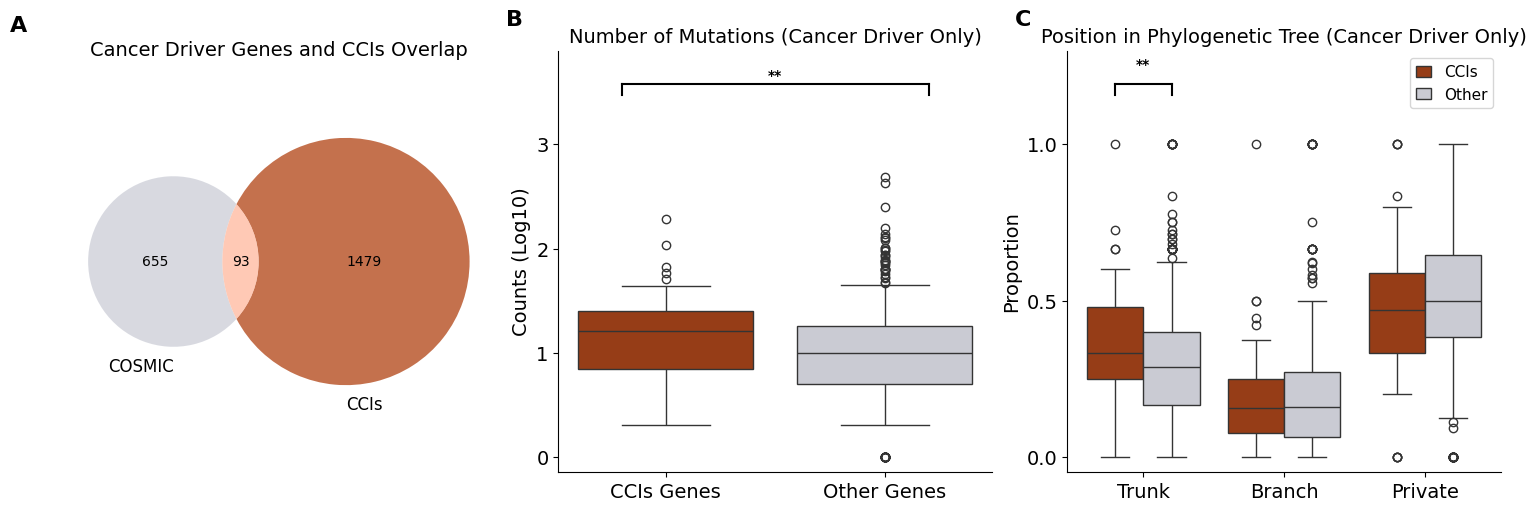

In [17]:
plot_gene_analysis(
    cosmic_results,
    lr,
    cosmic,
    all_mutationsdf,
    #save_path="/home/lnemati/pathway_crosstalk/results/supplementary/cosmic_mutations"   # will save as PNG and PDF
)

In [18]:
#cosmic_mutationsdf = cosmic_mutationsdf[~cosmic_mutationsdf['gene'].isin(length.index)]

In [19]:
def run_gene_analysis_normalized(mutationsdf, lr, gene_length):

    import numpy as np
    import pandas as pd
    from scipy.stats import mannwhitneyu

    # -----------------------------
    # 1. Count mutations per gene per time
    # -----------------------------
    counts = mutationsdf.groupby(['unique_id', 'when']).size().reset_index(name='count')

    counts['patient'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[:-1]))
    counts['gene'] = counts['unique_id'].str.split('_').apply(lambda x: x[-1])

    counts = counts[counts['gene'].isin(gene_length.index)]

    # -----------------------------
    # 2. Aggregate
    # -----------------------------
    genes = counts.groupby(['gene', 'when'])['count'].sum().to_frame()

    genes['gene'] = genes.index.get_level_values(0)
    genes['when'] = genes.index.get_level_values(1)
    genes.index = range(len(genes))

    # -----------------------------
    # 3. Normalize
    # -----------------------------
    genes['gene_len'] = genes['gene'].map(gene_length) / 1e6 # mega base pair
    genes = genes.dropna(subset=['gene_len'])
    genes['norm_count'] = genes['count'] / genes['gene_len']

    # -----------------------------
    # 4. Pivot
    # -----------------------------
    genes_pivot = genes.pivot(index='gene', columns='when', values='norm_count').fillna(0)

    total_norm = genes_pivot.sum(axis=1)
    genes_pivot = genes_pivot.loc[total_norm.sort_values(ascending=False).index]

    # -----------------------------
    # 5. CCC split
    # -----------------------------
    genes_pivot_ccc = genes_pivot.loc[genes_pivot.index.isin(lr)]
    genes_pivot_not_ccc = genes_pivot.loc[~genes_pivot.index.isin(lr)]

    results = pd.DataFrame(columns=['auroc', 'pval'])

    # -----------------------------
    # 6. TOTAL (NORMALIZED)
    # -----------------------------
    norm_total_ccc_log10 = np.log10(genes_pivot_ccc.sum(axis=1) + 1e-12)
    norm_total_not_ccc_log10 = np.log10(genes_pivot_not_ccc.sum(axis=1) + 1e-12)

    result = mannwhitneyu(norm_total_ccc_log10, norm_total_not_ccc_log10)

    results.loc['log10 Total (normalized)', 'auroc'] = (
        result.statistic /
        (len(norm_total_ccc_log10) * len(norm_total_not_ccc_log10))
    )
    results.loc['log10 Total (normalized)', 'pval'] = result.pvalue

    # -----------------------------
    # 7. DISTRIBUTION
    # -----------------------------
    genes_ccc_norm = genes_pivot_ccc.T.div(genes_pivot_ccc.sum(axis=1)).T
    genes_not_ccc_norm = genes_pivot_not_ccc.T.div(genes_pivot_not_ccc.sum(axis=1)).T

    for col in genes_pivot.columns:

        result = mannwhitneyu(
            genes_ccc_norm[col],
            genes_not_ccc_norm[col]
        )

        results.loc[col, 'auroc'] = result.statistic / (
            genes_ccc_norm.shape[0] * genes_not_ccc_norm.shape[0]
        )
        results.loc[col, 'pval'] = result.pvalue

    # -----------------------------
    # 8. FDR
    # -----------------------------
    results['pval_adj'] = false_discovery_control(results['pval'].astype(float).values)

    results = results.loc[['log10 Total (normalized)', 'Trunk', 'Branch', 'Private']]

    #return {
    #    "results": results,
    #    "genes_ccc_norm": genes_pivot_ccc,
    #    "genes_not_ccc_norm": genes_pivot_not_ccc,
    #    "norm_total_ccc_log10": norm_total_ccc_log10,
    #    "norm_total_not_ccc_log10": norm_total_not_ccc_log10
    #}
    return {
        "results": results,

        # true composition matrices (sum to 1 per gene)
        "genes_ccc_norm": genes_ccc_norm,
        "genes_not_ccc_norm": genes_not_ccc_norm,

        "norm_total_ccc_log10": norm_total_ccc_log10,
        "norm_total_not_ccc_log10": norm_total_not_ccc_log10
    }

In [20]:
output = run_gene_analysis_normalized(
    mutationsdf=cosmic_mutationsdf,
    lr=lr,                      # same as your original CCC list
    gene_length = length
)

output["results"]

,auroc,pval,pval_adj
log10 Total (normalized),0.623945,0.000116,0.000462
Trunk,0.60151,0.001571,0.003141
Branch,0.47753,0.482417,0.482417
Private,0.442386,0.07297,0.097294


/var/tmp/pbs.437332.pbs01/ipykernel_335536/2615280840.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes['B'].legend().remove()


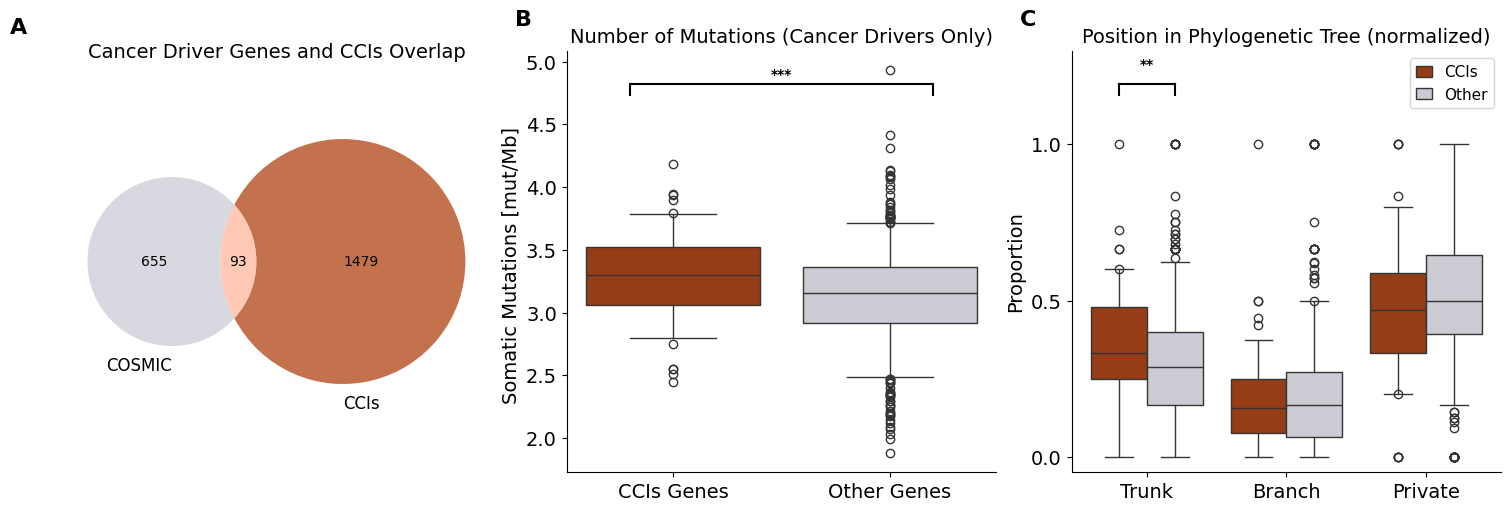

In [21]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_gene_analysis(res_dict, lr, cosmic, title=None, save_path=None):

    results = res_dict["results"]

    norm_total_ccc_log10 = res_dict["norm_total_ccc_log10"]
    norm_total_not_ccc_log10 = res_dict["norm_total_not_ccc_log10"]

    genes_ccc_norm = res_dict["genes_ccc_norm"]
    genes_not_ccc_norm = res_dict["genes_not_ccc_norm"]

    fs = 14
    smallfs = 11

    fig, axes = plt.subplot_mosaic(
        """
        ABC
        """,
        figsize=(15,5),
        constrained_layout=True
    )

    # -----------------------
    # Panel A: Venn diagram
    # -----------------------
    cci_genes = set(lr)
    cosmic_genes = set(cosmic)

    venn2(
        [cosmic_genes, cci_genes],
        set_labels=('COSMIC', 'CCIs'),
        set_colors=(lightgray, tcolor),
        alpha=0.7,
        ax=axes['A']
    )
    axes['A'].set_title('Cancer Driver Genes and CCIs Overlap', fontsize=fs, y=1.16)

    # -----------------------
    # Build plotting dataframe
    # -----------------------
    data = pd.DataFrame({
        'Comparison': (
            ['log10 Total (norm)'] * len(norm_total_ccc_log10) +
            ['log10 Total (norm)'] * len(norm_total_not_ccc_log10) +
            ['Trunk'] * len(genes_ccc_norm['Trunk']) +
            ['Trunk'] * len(genes_not_ccc_norm['Trunk']) +
            ['Branch'] * len(genes_ccc_norm['Branch']) +
            ['Branch'] * len(genes_not_ccc_norm['Branch']) +
            ['Private'] * len(genes_ccc_norm['Private']) +
            ['Private'] * len(genes_not_ccc_norm['Private'])
        ),
        'Gene Type': (
            ['CCIs Genes'] * len(norm_total_ccc_log10) +
            ['Other Genes'] * len(norm_total_not_ccc_log10) +
            ['CCIs Genes'] * len(genes_ccc_norm['Trunk']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Trunk']) +
            ['CCIs Genes'] * len(genes_ccc_norm['Branch']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Branch']) +
            ['CCIs Genes'] * len(genes_ccc_norm['Private']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Private'])
        ),
        'Value': np.concatenate([
            norm_total_ccc_log10,
            norm_total_not_ccc_log10,
            genes_ccc_norm['Trunk'],
            genes_not_ccc_norm['Trunk'],
            genes_ccc_norm['Branch'],
            genes_not_ccc_norm['Branch'],
            genes_ccc_norm['Private'],
            genes_not_ccc_norm['Private']
        ])
    })

    counts = data.query('Comparison == "log10 Total (norm)"')
    fracs = data.query('Comparison != "log10 Total (norm)"')

    # -----------------------
    # Panel B: Total normalized burden
    # -----------------------
    sns.boxplot(
        x='Gene Type',
        y='Value',
        hue='Gene Type',
        data=counts,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axes['B'],
        whis=[5,95]
    )
    axes['B'].set_title('Number of Mutations (Cancer Drivers Only)', fontsize=fs)
    axes['B'].set_xlabel("")
    axes['B'].set_ylabel("Somatic Mutations [mut/Mb] ")
    axes['B'].legend().remove()

    # -----------------------
    # Panel C: Tree position distribution
    # -----------------------
    sns.boxplot(
        x='Comparison',
        y='Value',
        hue='Gene Type',
        data=fracs,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axes['C'],
        whis=[5,95]
    )
    axes['C'].set_title('Position in Phylogenetic Tree (normalized)', fontsize=fs)
    axes['C'].set_xlabel("")
    axes['C'].set_ylabel("Proportion")
    axes['C'].set_ylim(-0.05,1.3)
    axes['C'].set_yticks([0,0.5,1])

    handles, labels = axes['C'].get_legend_handles_labels()
    new_labels = ['CCIs' if 'CCIs' in l else 'Other' for l in labels]
    axes['C'].legend(handles, new_labels, fontsize=smallfs, handlelength=1)

    # -----------------------
    # Significance bars
    # -----------------------
    for i, (comparison, row) in enumerate(results.iterrows()):

        if comparison == "log10 Total (normalized)":
            ax = axes['B']
            x_positions = [0,1]
        else:
            ax = axes['C']
            x_positions = [i-1]

        if row['pval_adj'] < 0.05:

            lims = ax.get_ylim()
            yrange = lims[1] - lims[0]
            y = lims[0] + 0.92 * yrange

            stars = '*'*(1+(row['pval_adj']<0.01)+(row['pval_adj']<0.001))

            if ax == axes['B']:
                ax.plot([x_positions[0]-0.2, x_positions[1]+0.2], [y,y], color='black')
                ax.plot([x_positions[0]-0.2, x_positions[0]-0.2], [y-0.025*yrange,y], color='black')
                ax.plot([x_positions[1]+0.2, x_positions[1]+0.2], [y-0.025*yrange,y], color='black')
                ax.text(0.5, y+0.05, stars, ha='center', weight='bold')
            else:
                x = x_positions[0]
                ax.plot([x-0.2, x+0.2], [y,y], color='black')
                ax.plot([x-0.2, x-0.2], [y-0.025*yrange,y], color='black')
                ax.plot([x+0.2, x+0.2], [y-0.025*yrange,y], color='black')
                ax.text(x, y+0.05, stars, ha='center', weight='bold')

    # -----------------------
    # Styling
    # -----------------------
    for ax in axes.values():
        ax.title.set_fontsize(fs)
        ax.xaxis.label.set_fontsize(fs)
        ax.yaxis.label.set_fontsize(fs)
        ax.tick_params(axis='both', labelsize=fs, direction='out')
        ax.grid(False)
        ax.spines[['right','top']].set_visible(False)

    axes['A'].text(-0.12,1.27,'A',transform=axes['A'].transAxes,
                   fontsize=16,fontweight='bold')
    axes['B'].text(-0.12,1.06,'B',transform=axes['B'].transAxes,
                   fontsize=16,fontweight='bold')
    axes['C'].text(-0.12,1.06,'C',transform=axes['C'].transAxes,
                   fontsize=16,fontweight='bold')

    if title:
        fig.suptitle(title, fontsize=fs+2)

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        fig.savefig(f"{save_path}.pdf", dpi=300, bbox_inches='tight')

    plt.show()
    
plot_gene_analysis(
    output,
    lr,
    cosmic
)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_gene_analysis_BC_only(res_dict):

    norm_total_ccc_log10 = res_dict["norm_total_ccc_log10"]
    norm_total_not_ccc_log10 = res_dict["norm_total_not_ccc_log10"]

    genes_ccc_norm = res_dict["genes_ccc_norm"]
    genes_not_ccc_norm = res_dict["genes_not_ccc_norm"]

    fs = 14
    smallfs = 11

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    axB, axC = axes

    # -----------------------
    # Build plotting dataframe
    # -----------------------
    data = pd.DataFrame({
        'Comparison': (
            ['log10 Total (norm)'] * len(norm_total_ccc_log10) +
            ['log10 Total (norm)'] * len(norm_total_not_ccc_log10) +
            ['Trunk'] * len(genes_ccc_norm['Trunk']) +
            ['Trunk'] * len(genes_not_ccc_norm['Trunk']) +
            ['Branch'] * len(genes_ccc_norm['Branch']) +
            ['Branch'] * len(genes_not_ccc_norm['Branch']) +
            ['Private'] * len(genes_ccc_norm['Private']) +
            ['Private'] * len(genes_not_ccc_norm['Private'])
        ),
        'Gene Type': (
            ['CCIs Genes'] * len(norm_total_ccc_log10) +
            ['Other Genes'] * len(norm_total_not_ccc_log10) +
            ['CCIs Genes'] * len(genes_ccc_norm['Trunk']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Trunk']) +
            ['CCIs Genes'] * len(genes_ccc_norm['Branch']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Branch']) +
            ['CCIs Genes'] * len(genes_ccc_norm['Private']) +
            ['Other Genes'] * len(genes_not_ccc_norm['Private'])
        ),
        'Value': np.concatenate([
            norm_total_ccc_log10,
            norm_total_not_ccc_log10,
            genes_ccc_norm['Trunk'],
            genes_not_ccc_norm['Trunk'],
            genes_ccc_norm['Branch'],
            genes_not_ccc_norm['Branch'],
            genes_ccc_norm['Private'],
            genes_not_ccc_norm['Private']
        ])
    })

    counts = data.query('Comparison == "log10 Total (norm)"')
    fracs = data.query('Comparison != "log10 Total (norm)"')

    # -----------------------
    # Panel B: Total normalized burden
    # -----------------------
    sns.boxplot(
        x='Gene Type',
        y='Value',
        hue='Gene Type',
        data=counts,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axB,
        whis=[5, 95]
    )

    axB.set_title('Number of Mutations (Cancer Drivers Only)', fontsize=fs)
    axB.set_xlabel("")
    axB.set_ylabel("Somatic Mutations [mut/Mb]")
    axB.legend().remove()

    # -----------------------
    # Panel C: Tree position distribution
    # -----------------------
    sns.boxplot(
        x='Comparison',
        y='Value',
        hue='Gene Type',
        data=fracs,
        palette={'CCIs Genes': tcolor, 'Other Genes': lightgray},
        ax=axC,
        whis=[5, 95]
    )

    axC.set_title('Position in Phylogenetic Tree (normalized)', fontsize=fs)
    axC.set_xlabel("")
    axC.set_ylabel("Proportion")
    axC.set_ylim(-0.05, 1.3)
    axC.set_yticks([0, 0.5, 1])

    handles, labels = axC.get_legend_handles_labels()
    new_labels = ['CCIs' if 'CCIs' in l else 'Other' for l in labels]
    axC.legend(handles, new_labels, fontsize=smallfs, handlelength=1)

    # -----------------------
    # Significance bars
    # -----------------------
    for i, (comparison, row) in enumerate(res_dict["results"].iterrows()):

        if comparison == "log10 Total (normalized)":
            ax = axB
            x_positions = [0, 1]
        else:
            ax = axC
            x_positions = [i - 1]

        if row['pval_adj'] < 0.05:

            lims = ax.get_ylim()
            yrange = lims[1] - lims[0]
            y = lims[0] + 0.92 * yrange

            stars = '*' * (1 + (row['pval_adj'] < 0.01) + (row['pval_adj'] < 0.001))

            if ax == axB:
                ax.plot([x_positions[0]-0.2, x_positions[1]+0.2], [y, y], color='black')
                ax.plot([x_positions[0]-0.2, x_positions[0]-0.2], [y-0.025*yrange, y], color='black')
                ax.plot([x_positions[1]+0.2, x_positions[1]+0.2], [y-0.025*yrange, y], color='black')
                ax.text(0.5, y+0.05, stars, ha='center', weight='bold')
            else:
                x = x_positions[0]
                ax.plot([x-0.2, x+0.2], [y, y], color='black')
                ax.plot([x-0.2, x-0.2], [y-0.025*yrange, y], color='black')
                ax.plot([x+0.2, x+0.2], [y-0.025*yrange, y], color='black')
                ax.text(x, y+0.05, stars, ha='center', weight='bold')

    # -----------------------
    # Styling
    # -----------------------
    for ax in axes:
        ax.title.set_fontsize(fs)
        ax.xaxis.label.set_fontsize(fs)
        ax.yaxis.label.set_fontsize(fs)
        ax.tick_params(axis='both', labelsize=fs, direction='out')
        ax.grid(False)
        ax.spines[['right', 'top']].set_visible(False)

    plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/cosmic_mutations.png", bbox_inches='tight', dpi=300)
    plt.savefig("/home/lnemati/pathway_crosstalk/results/revision/cosmic_mutations.pdf", bbox_inches='tight', dpi=300)
        
    plt.show()

/var/tmp/pbs.437332.pbs01/ipykernel_335536/2263491905.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axB.legend().remove()


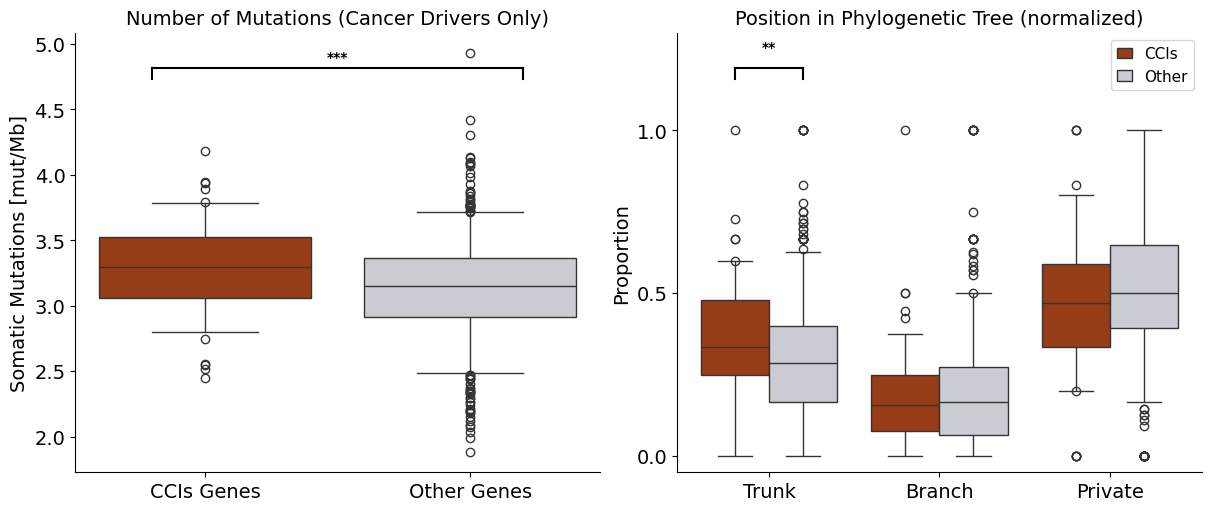

In [23]:
plot_gene_analysis_BC_only(
    output,
)